<a href="https://colab.research.google.com/github/rafiadpr/244107020026-mobile-course/blob/main/modul_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# D. PRAKTIKUM FILTER

1. Buat fungsi konvolusi menggunakan algoritma yang telah dijelaskan pada Bagian C, tanpa menggunakan library atau metode konvolusi dari OpenCV.

Silakan upload gambar:


Saving djawatan.jpg to djawatan.jpg


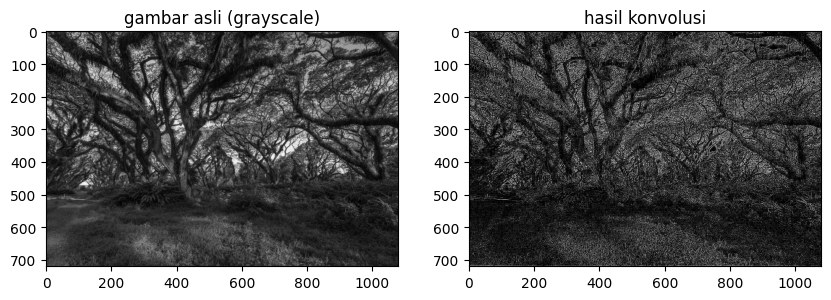

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

print("Silakan upload gambar:")
uploaded = files.upload()
file_name = next(iter(uploaded))

# membaca gambar asli yang diupload
image = cv2.imread(file_name)

# mengubah gambar menjadi hitam putih (grayscale) agar lebih mudah diproses
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# mengambil nilai tinggi dan lebar dari gambar
tinggi_gambar, lebar_gambar = image_gray.shape

# membuat matriks kernel untuk filter (contoh ini menggunakan filter deteksi tepi)
kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# mengambil nilai tinggi dan lebar dari kernel
tinggi_kernel, lebar_kernel = kernel.shape

# menghitung ukuran bingkai tambahan (padding)
pad_tinggi = tinggi_kernel // 2
pad_lebar = lebar_kernel // 2

# menambahkan bingkai piksel bernilai 0 di sekeliling gambar asli
gambar_berbingkai = np.pad(image_gray, ((pad_tinggi, pad_tinggi), (pad_lebar, pad_lebar)), mode='constant', constant_values=0)

# menyiapkan kanvas kosong berlatar hitam untuk menyimpan hasil akhir
hasil = np.zeros_like(image_gray, dtype=np.float32)

# proses konvolusi (menggeser kernel dari ujung kiri atas ke kanan bawah gambar)
for y in range(tinggi_gambar):
    for x in range(lebar_gambar):

        # memotong area gambar yang sedang tertimpa oleh kotak kernel
        area_gambar = gambar_berbingkai[y:y+tinggi_kernel, x:x+lebar_kernel]

        # mengalikan piksel gambar dengan nilai kernel, lalu menjumlahkan semuanya
        nilai_baru = np.sum(area_gambar * kernel)

        # menyimpan hasil penjumlahan ke kanvas kosong yang tadi disiapkan
        hasil[y, x] = nilai_baru

# memastikan nilai piksel tidak ada yang minus dan tidak melebihi angka 255
hasil = np.clip(hasil, 0, 255).astype(np.uint8)

# menampilkan gambar asli dan gambar hasil bersebelahan
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_gray, cmap='gray')
plt.title("gambar asli (grayscale)")

plt.subplot(1, 2, 2)
plt.imshow(hasil, cmap='gray')
plt.title("hasil konvolusi")

plt.show()

c. Buatlah fungsi konvolusi. Catatan: parameter yang digunakan boleh dimodifikasi. Misal, hanya menggunakan parameter image dan kernel saja, atau image, kernel, dan padding.

d. Load citra yang akan diproses dan ubah menjadi citra keabuan

e. Tentukan kernel yang akan digunakan, contohnya kernel untuk filter sharpening sebagai berikut:

In [ ]:
# menyambungkan google colab ke google drive
drive.mount('/content/drive')

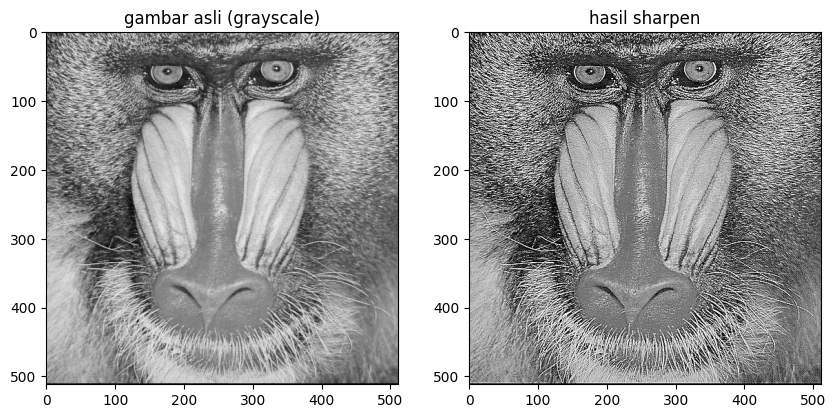

In [5]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from google.colab import drive

# poin c: membuat fungsi konvolusi sesuai format dari modul
def convolution2d(image, kernel, stride, padding):
    # menambahkan bingkai (padding) pada gambar dengan nilai 0
    gambar_berbingkai = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)

    # mengambil ukuran tinggi dan lebar dari gambar dan kernel
    tinggi_gambar, lebar_gambar = image.shape
    tinggi_kernel, lebar_kernel = kernel.shape

    # menghitung ukuran gambar hasil setelah dikonvolusi dan dibagi stride
    tinggi_hasil = int(((tinggi_gambar + 2 * padding - tinggi_kernel) / stride) + 1)
    lebar_hasil = int(((lebar_gambar + 2 * padding - lebar_kernel) / stride) + 1)

    # menyiapkan kanvas kosong untuk menyimpan hasil akhir
    hasil = np.zeros((tinggi_hasil, lebar_hasil), dtype=np.float32)

    # proses pergeseran kernel ke seluruh bagian gambar
    for y in range(tinggi_hasil):
        for x in range(lebar_hasil):
            # menentukan titik awal dan titik akhir potongan gambar sesuai pergeseran (stride)
            y_awal = y * stride
            y_akhir = y_awal + tinggi_kernel
            x_awal = x * stride
            x_akhir = x_awal + lebar_kernel

            # memotong area gambar yang sedang ditutupi oleh kernel
            area_gambar = gambar_berbingkai[y_awal:y_akhir, x_awal:x_akhir]

            # mengalikan piksel gambar dengan kernel lalu dijumlahkan
            nilai_baru = np.sum(area_gambar * kernel)

            # menyimpan hasil hitungan ke dalam kanvas
            hasil[y, x] = nilai_baru

    # memastikan nilai akhir tetap di batas normal piksel (0 sampai 255)
    hasil = np.clip(hasil, 0, 255).astype(np.uint8)

    return hasil

# poin d: meload gambar dari google drive dan mengubahnya menjadi abu-abu
# pastikan path file ini benar sesuai lokasi file di google drive kamu
path_gambar = '/content/drive/MyDrive/Politeknik Negeri Malang/PCVK/mandrill.tiff'
img = cv.imread(path_gambar)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# poin e: menentukan kernel sharpen
kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

# menjalankan fungsi konvolusi2d dengan nilai stride 1 dan padding 1
hasil_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1)

# menampilkan gambar asli dan hasil penajaman (sharpen)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap='gray')
plt.title("gambar asli (grayscale)")

plt.subplot(1, 2, 2)
plt.imshow(hasil_sharpen, cmap='gray')
plt.title("hasil sharpen")

plt.show()

f. Memanggil fungsi konvolusi yang telah dibuat sebelumnya, dan menampilkan hasil konvolusinya:

3. Buat Image Filter untuk Average filter, low pass filter, high pass filter, dan beberapa filter berikut:

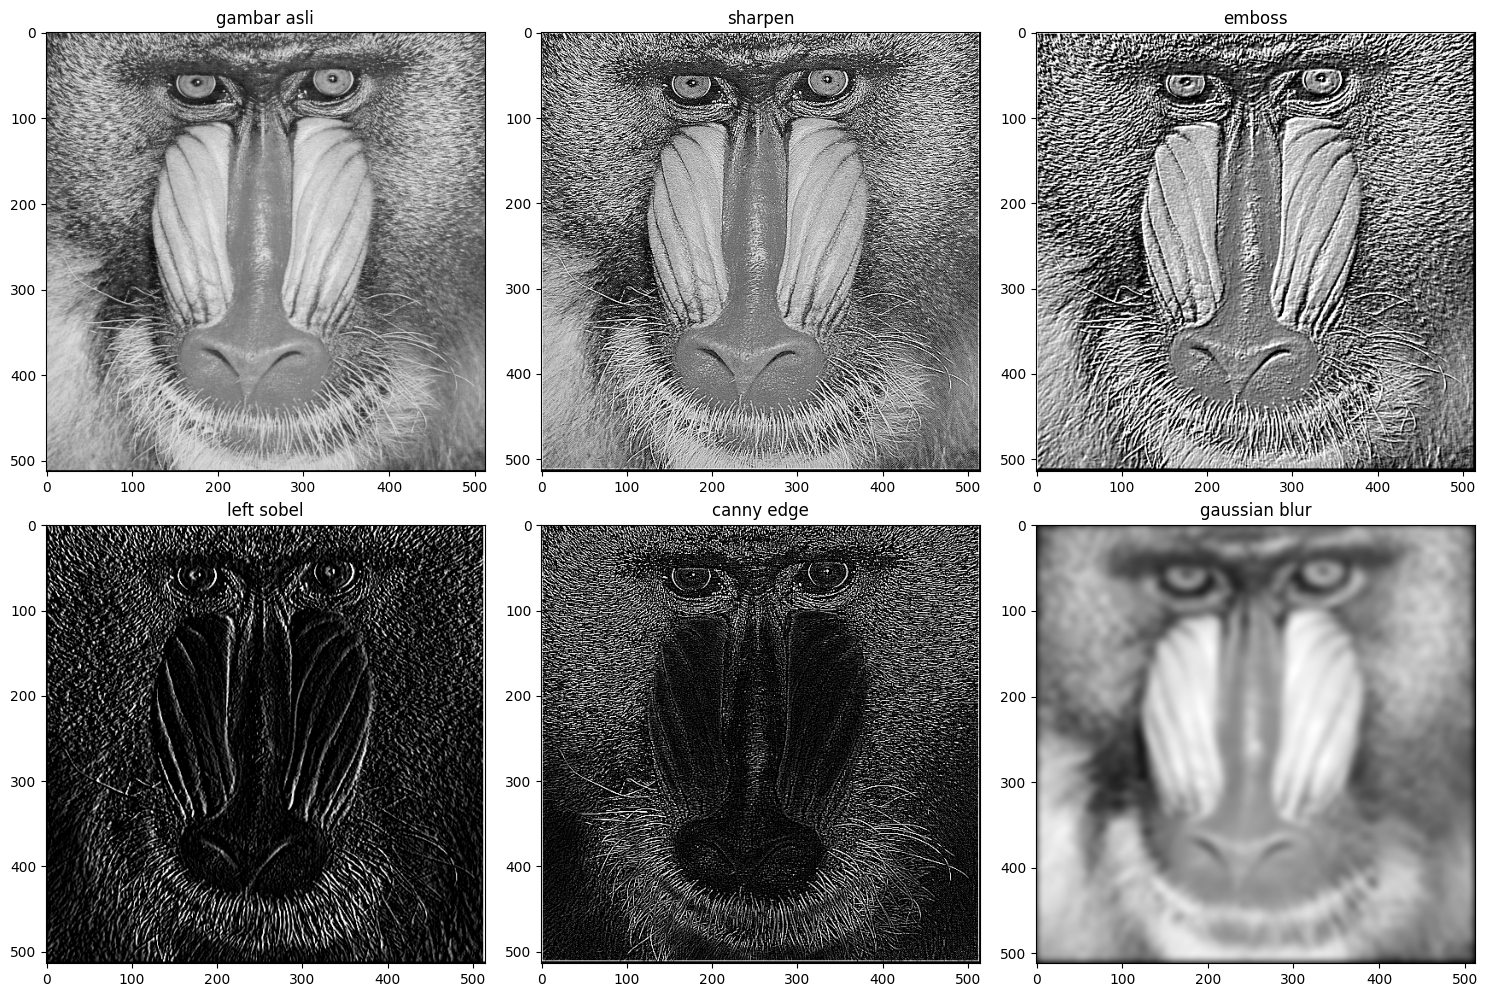

In [7]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import math
from google.colab import drive

# membuat fungsi konvolusi 2d
def convolution2d(image, kernel, stride, padding):
    # menambahkan bingkai pada gambar
    gambar_berbingkai = np.pad(image, ((padding, padding), (padding, padding)), mode='constant', constant_values=0)

    # mengambil ukuran gambar dan kernel
    tinggi_gambar, lebar_gambar = image.shape
    tinggi_kernel, lebar_kernel = kernel.shape

    # menghitung ukuran gambar hasil
    tinggi_hasil = int(((tinggi_gambar + 2 * padding - tinggi_kernel) / stride) + 1)
    lebar_hasil = int(((lebar_gambar + 2 * padding - lebar_kernel) / stride) + 1)

    # menyiapkan tempat kosong untuk gambar hasil
    hasil = np.zeros((tinggi_hasil, lebar_hasil), dtype=np.float32)

    # proses pergeseran kernel pada gambar
    for y in range(tinggi_hasil):
        for x in range(lebar_hasil):
            # menentukan batas area potongan gambar
            y_awal = y * stride
            y_akhir = y_awal + tinggi_kernel
            x_awal = x * stride
            x_akhir = x_awal + lebar_kernel

            # memotong bagian gambar
            area_gambar = gambar_berbingkai[y_awal:y_akhir, x_awal:x_akhir]

            # menghitung nilai piksel baru dengan perkalian matriks
            nilai_baru = np.sum(area_gambar * kernel)
            hasil[y, x] = nilai_baru

    # membatasi nilai piksel dari 0 sampai 255
    hasil = np.clip(hasil, 0, 255).astype(np.uint8)
    return hasil

# meload gambar dari google drive
# pastikan lokasi file sudah sesuai dengan yang ada di drive
path_gambar = '/content/drive/MyDrive/Politeknik Negeri Malang/PCVK/mandrill.tiff'
img = cv.imread(path_gambar)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# membuat matriks untuk filter sharpen
kernel_sharpen = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

# membuat matriks untuk filter emboss
kernel_emboss = np.array([
    [-2, -1,  0],
    [-1,  1,  1],
    [ 0,  1,  2]
])

# membuat matriks untuk filter left sobel
kernel_left_sobel = np.array([
    [ 1,  0, -1],
    [ 2,  0, -2],
    [ 1,  0, -1]
])

# membuat matriks untuk filter canny edge
kernel_canny = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# membuat matriks untuk gaussian blur
ukuran_kernel = 21
sigma = math.sqrt(ukuran_kernel)
kernel_gaussian_1d = cv.getGaussianKernel(ukuran_kernel, sigma)
kernel_gaussian = kernel_gaussian_1d @ kernel_gaussian_1d.transpose()

# menjalankan fungsi konvolusi untuk masing masing filter
hasil_sharpen = convolution2d(img_gray, kernel_sharpen, stride=1, padding=2)
hasil_emboss = convolution2d(img_gray, kernel_emboss, stride=1, padding=2)
hasil_left_sobel = convolution2d(img_gray, kernel_left_sobel, stride=1, padding=2)
hasil_canny = convolution2d(img_gray, kernel_canny, stride=1, padding=2)

# menghitung padding khusus untuk gaussian blur agar gambar tidak terpotong
padding_gaussian = ukuran_kernel // 2
hasil_gaussian = convolution2d(img_gray, kernel_gaussian, stride=1, padding=padding_gaussian)

# menampilkan semua hasil filter
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(img_gray, cmap='gray')
plt.title("gambar asli")

plt.subplot(2, 3, 2)
plt.imshow(hasil_sharpen, cmap='gray')
plt.title("sharpen")

plt.subplot(2, 3, 3)
plt.imshow(hasil_emboss, cmap='gray')
plt.title("emboss")

plt.subplot(2, 3, 4)
plt.imshow(hasil_left_sobel, cmap='gray')
plt.title("left sobel")

plt.subplot(2, 3, 5)
plt.imshow(hasil_canny, cmap='gray')
plt.title("canny edge")

plt.subplot(2, 3, 6)
plt.imshow(hasil_gaussian, cmap='gray')
plt.title("gaussian blur")

plt.tight_layout()
plt.show()